## Task 1: LSTM for Next Step Prediction

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

steps = np.array([4000, 4200, 4300, 4100, 4500, 4700, 4800, 5000], dtype=float)

X = []
y = []

for i in range(len(steps) - 3):
    X.append(steps[i:i+3])
    y.append(steps[i+3])

X = np.array(X)
y = np.array(y)

X = X.reshape((X.shape[0], X.shape[1], 1))

model = Sequential([LSTM(32, input_shape=(3, 1)), Dense(1)])
model.compile(optimizer="adam", loss="mse")
model.fit(X, y, epochs=20, verbose=0)

last_sequence = np.array([4700, 4800, 5000], dtype=float)
last_sequence = last_sequence.reshape((1, 3, 1))

prediction = model.predict(last_sequence)

print("Predicted next step count:", prediction[0][0])

C:\Users\Kirtan\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
Predicted next step count: 0.2704721


## Task 2 — Vanishing Gradient in a Basic RNN

In [11]:
import numpy as np 
import tensorflow as tf

tf.random.set_seed(42)

X = np.array(
    [[0, 1, 0, 1, 0, 1, 0, 1, 0, 1]],
    dtype=np.float32)

X = X.reshape(1, 10, 1) 
Y = np.array([[1]], dtype=np.float32)

rnn = tf.keras.layers.SimpleRNN(
    8,
    return_sequences=True,
    return_state=True)

dense = tf.keras.layers.Dense(1, activation="sigmoid")
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01)

for epochs in range(5):
    with tf.GradientTape() as tape:
        outputs, final_state = rnn(X)
        prediction = dense(final_state)
        loss = tf.keras.losses.binary_crossentropy(Y, prediction)
        loss = tf.reduce_mean(loss)

        trainable_vars = rnn.trainable_weights + dense.trainable_weights
        
        gradients = tape.gradient(loss, trainable_vars)

        optimizer.apply_gradients(zip(gradients, trainable_vars))

        print("\nEpochs:", epochs + 1)
        print("\nLoss:", loss.numpy())

        for i, grad in enumerate(gradients):
            if grad is not None:
                print("\n"
                "Gradient", i,
                "mean =",
                tf.reduce_mean(tf.abs(grad)).numpy()
                )

optimizer.apply_gradients(zip(gradients, trainable_vars))
print()


Epochs: 1

Loss: 0.6705752

Gradient 0 mean = 0.17403738

Gradient 1 mean = 0.08656772

Gradient 2 mean = 0.27001765

Gradient 3 mean = 0.16524479

Gradient 4 mean = 0.48858568

Epochs: 2

Loss: 0.6445902

Gradient 0 mean = 0.15810749

Gradient 1 mean = 0.08122245

Gradient 2 mean = 0.23984714

Gradient 3 mean = 0.16760144

Gradient 4 mean = 0.4751224

Epochs: 3

Loss: 0.6227389

Gradient 0 mean = 0.14499956

Gradient 1 mean = 0.076864675

Gradient 2 mean = 0.21477537

Gradient 3 mean = 0.16893852

Gradient 4 mean = 0.4635269

Epochs: 4

Loss: 0.60388833

Gradient 0 mean = 0.13437127

Gradient 1 mean = 0.07333612

Gradient 2 mean = 0.19434679

Gradient 3 mean = 0.16955175

Gradient 4 mean = 0.45331818

Epochs: 5

Loss: 0.5872086

Gradient 0 mean = 0.12571394

Gradient 1 mean = 0.07045651

Gradient 2 mean = 0.17768548

Gradient 3 mean = 0.16964743

Gradient 4 mean = 0.4441232



## Task 3:  LSTM Cell Architecture

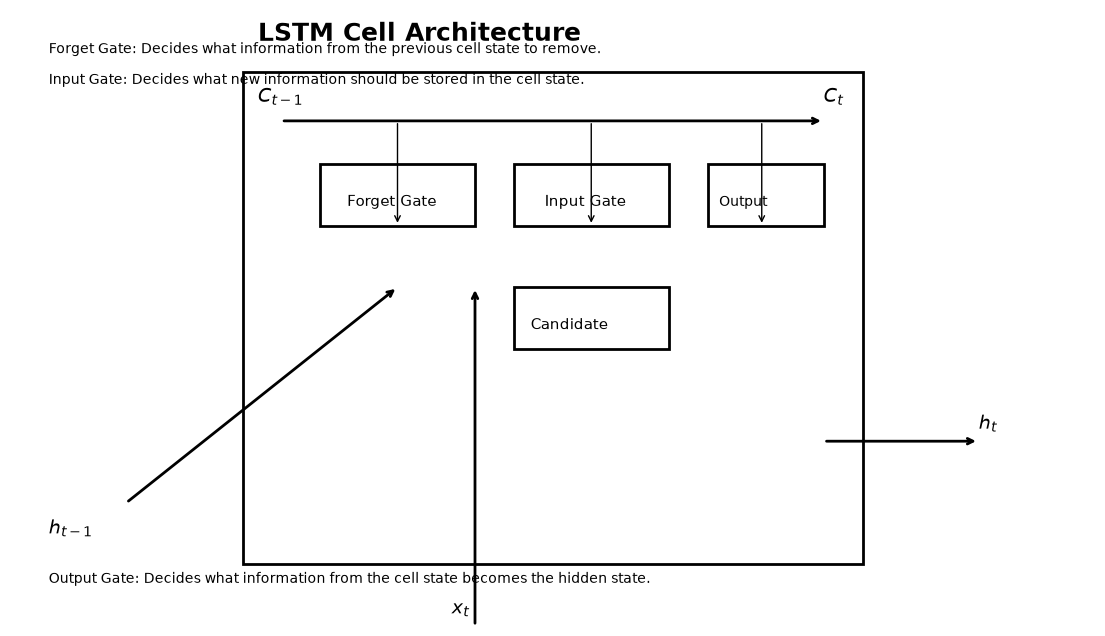

In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch

fig, ax = plt.subplots(figsize=(14, 8))

ax.set_xlim(0, 14)
ax.set_ylim(0, 10)
ax.axis("off")


ax.add_patch(Rectangle((3, 1), 8, 8, fill=False, linewidth=2))


ax.annotate(
    "",
    xy=(10.5, 8.2),
    xytext=(3.5, 8.2),
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

ax.text(3.2, 8.5, r"$C_{t-1}$", fontsize=14)
ax.text(10.5, 8.5, r"$C_t$", fontsize=14)


ax.annotate(
    "",
    xy=(5, 5.5),
    xytext=(1.5, 2),
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

ax.text(0.5, 1.5, r"$h_{t-1}$", fontsize=14)


ax.annotate(
    "",
    xy=(6, 5.5),
    xytext=(6, 0),
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

ax.text(5.7, 0.2, r"$x_t$", fontsize=14)


ax.add_patch(Rectangle((4, 6.5), 2, 1, fill=False, linewidth=2))
ax.text(4.35, 6.82, "Forget Gate", fontsize=11)


ax.add_patch(Rectangle((6.5, 6.5), 2, 1, fill=False, linewidth=2))
ax.text(6.9, 6.82, "Input Gate", fontsize=11)


ax.add_patch(Rectangle((6.5, 4.5), 2, 1, fill=False, linewidth=2))
ax.text(6.72, 4.82, "Candidate", fontsize=11)


ax.add_patch(Rectangle((9, 6.5), 1.5, 1, fill=False, linewidth=2))
ax.text(9.15, 6.82, "Output", fontsize=10)


ax.annotate(
    "",
    xy=(12.5, 3),
    xytext=(10.5, 3),
    arrowprops=dict(arrowstyle="->", linewidth=2)
)

ax.text(12.5, 3.2, r"$h_t$", fontsize=14)


ax.annotate(
    "",
    xy=(5, 6.5),
    xytext=(5, 8.2),
    arrowprops=dict(arrowstyle="->")
)

ax.annotate(
    "",
    xy=(7.5, 6.5),
    xytext=(7.5, 8.2),
    arrowprops=dict(arrowstyle="->")
)

ax.annotate(
    "",
    xy=(9.7, 6.5),
    xytext=(9.7, 8.2),
    arrowprops=dict(arrowstyle="->")
)


ax.text(
    0.5, 9.3,
    "Forget Gate: Decides what information from the previous cell state to remove.",
    fontsize=10
)

ax.text(
    0.5, 8.8,
    "Input Gate: Decides what new information should be stored in the cell state.",
    fontsize=10
)

ax.text(
    0.5, 0.7,
    "Output Gate: Decides what information from the cell state becomes the hidden state.",
    fontsize=10
)

ax.text(
    3.2, 9.5,
    "LSTM Cell Architecture",
    fontsize=18,
    fontweight="bold"
)

plt.show()

## Task 4: LSTM Information Flow for Food Orders

In [14]:
orders = ["pizza", "burger", "pasta", "pizza"] 

forget_gate_1 = 1
input_gate_1 = 1
output_gate_1 = 1

cell_state_1 = 1

print("Time Step 1:", orders[0])
print("Forget Gate:", forget_gate_1)
print("Input Gate:", input_gate_1)
print("Output Gate:", output_gate_1)
print("Cell State:", cell_state_1)

print()

forget_gate_2 = 0
input_gate_2 = 1
output_gate_2 = 1

cell_state_2 = 1

print("\nTime Step 2:", orders[1])
print("Forget Gate:", forget_gate_2)
print("Input Gate:", input_gate_2)
print("Output Gate:", output_gate_2)
print("Cell State:", cell_state_2)

print()

print("\nInformation Flow:")
print("Time 1: Keep pizza information")
print("Time 2: Forget previous pizza information and store burger")
print("Output: Use the updated information for prediction")

Time Step 1: pizza
Forget Gate: 1
Input Gate: 1
Output Gate: 1
Cell State: 1


Time Step 2: burger
Forget Gate: 0
Input Gate: 1
Output Gate: 1
Cell State: 1


Information Flow:
Time 1: Keep pizza information
Time 2: Forget previous pizza information and store burger
Output: Use the updated information for prediction


## Task 5: Unrolling an LSTM Through Time

In [15]:
playlist = ["Song A", "Song B", "Song C", "Song D"]

print("LSTM Unrolling Through Time:\n")

for t, song in enumerate(playlist):
    print("Time Step", t + 1, "->", song)

print("\nThe LSTM processes each song one at a time.")
print("The hidden state and cell state carry information from previous songs.")
print("This allows the model to learn the user's listening pattern.")
print("The learned pattern can be used to predict the next song.")

LSTM Unrolling Through Time:

Time Step 1 -> Song A
Time Step 2 -> Song B
Time Step 3 -> Song C
Time Step 4 -> Song D

The LSTM processes each song one at a time.
The hidden state and cell state carry information from previous songs.
This allows the model to learn the user's listening pattern.
The learned pattern can be used to predict the next song.
